# 02 · El modelo downstream: buscar una arquitectura válida

## Por qué este notebook existe
#### ***(Siguiendo un poco mi background clínico, lo primero es establecer un control en forma de un modelo que nos proporcione unos resultados base.)***

El enunciado pide "buscar una arquitectura de red neuronal válida" para el problema. Pero hay una razón más
importante que el enunciado: **el modelo downstream es nuestro instrumento de medida**. Todo el trabajo consiste en
comparar su error con y sin datos sintéticos, así que si la arquitectura cambiara entre experimentos estaríamos
midiendo búsqueda de arquitecturas, no calidad de datos.

Por eso este notebook hace una sola cosa: elegir la arquitectura **sobre datos 100% reales**, y congelarla. A partir
de aquí no se vuelve a tocar.

## Dos decisiones de diseño que conviene justificar antes de ver números

**Métrica principal: PR-AUC.** Con un 5-13% de positivos, la *accuracy* es inútil (un modelo que diga siempre "no"
acierta el 90%) y el ROC-AUC es demasiado optimista, porque el enorme número de negativos hace que la tasa de falsos
positivos se mueva poco. La precisión-recall se centra en la clase rara, que es la que nos importa. Reportamos el
**lift** = PR-AUC / tasa base, para que el número sea interpretable: el azar da 1.

**Sin pesos de clase.** Podríamos reequilibrar con `class_weight`, y mejoraría. No lo hacemos a propósito:
reequilibrar la clase minoritaria es exactamente el trabajo que queremos que hagan los datos sintéticos. Si lo
hiciéramos también en la función de pérdida, estaríamos tapando el efecto que intentamos medir.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

In [2]:
from src import config
print("EPOCHS =", config.DOWNSTREAM_EPOCHS)
print("PATIENCE =", config.DOWNSTREAM_PATIENCE)
print("BATCH =", config.DOWNSTREAM_BATCH)

EPOCHS = 100
PATIENCE = 100
BATCH = 128


In [3]:
from src import config, data, downstream, experiments, plots

split, returns, extras = data.load_problem()
print(f"Tasa base -> train {split.y_train.mean():.2%} | val {split.y_val.mean():.2%} | test {split.y_test.mean():.2%}")
print(f"Forma de entrada: {split.input_shape}")

tabla, historias = experiments.model_selection_table(split, force=True)

Tasa base -> train 5.00% | val 13.28% | test 7.79%
Forma de entrada: (60, 23)


## Los modelos de referencia

Antes de entrenar redes, hay que saber contra qué competimos. Dos predictores de una línea:

- **Volatilidad realizada** de la ventana. La volatilidad se agrupa, así que "últimamente ha habido turbulencia" ya
  es una predicción decente de turbulencia futura. Es el modelo mental de cualquier gestor de riesgo.
- **Drawdown actual** respecto al máximo de la ventana.

Y un modelo lineal: **regresión logística** sobre la ventana aplanada, que ocupa el hueco del "modelo lineal" en la
comparativa del profesor.

Cualquier red que no supere a estos tres no está aprendiendo nada que no supiéramos ya.

## Las variantes de CNN, y por qué la primera versión perdía contra el baseline

Partimos del esqueleto convolucional de su mejor regresor (`CNN 2`: tres bloques `Conv1D` + `MaxPooling`, luego una
cabeza densa), con salida sigmoide y dropout porque nuestros conjuntos de entrenamiento bajan hasta 500 ventanas.

#### ***(Tomando como inspiracion lo que nos enseñaste en clase)***

Las variantes comparadas son:

- `cnn_prof`: su arquitectura literal, con `padding="valid"`.
- `cnn_raw`: igual pero con `padding="same"`.
- `cnn_mag`: añade `|r|` como canales extra.
- `cnn_mag_bn`: con `BatchNormalization`.
- `cnn_mag_gap`: con `GlobalAveragePooling` en vez de `Flatten`.


#### ***(Por qué |r|? Nuestra primera CNN obtenía peores resultados que el baseline de volatilidad , lo cual es bastante lame, (PR-AUC de 0,39 frente a 0,45). La explicación que encontramos fue la siguiente:)***

Una capa convolucional calcula `Wx + b` seguido de un ReLU, y eso es una operación de **primer
orden**. Puede sumar, restar y umbralizar sus entradas, pero **no puede multiplicar dos de ellas**, así que no puede
calcular una varianza. Le estábamos pidiendo a la red que midiera volatilidad con una herramienta estructuralmente
incapaz de hacerlo.

Concatenar `|r|` a la entrada cuesta **cero parámetros**, no aprende nada (así que no puede sobreajustar ni filtrar
información) y, lo más importante, **mantiene la entrada del modelo como una ventana de retornos crudos**. Eso es
esencial: todos los generadores producen ventanas de retornos, así que siguen siendo directamente comparables por
mucho que la red haga transformaciones internas.

Esta misma idea reaparece dos veces más en el proyecto (en el discriminador de la GAN y en el modelo
autorregresivo). Está documentada en `src/layers.py`.

In [4]:
tabla, historias = experiments.model_selection_table(split)
cols = ["val_pr_auc", "val_lift", "test_pr_auc", "test_lift", "test_roc_auc", "test_recall", "test_precision"]
display(tabla[cols].round(3))

,val_pr_auc,val_lift,test_pr_auc,test_lift,test_roc_auc,test_recall,test_precision
Baseline: vol. realizada,0.685,5.159,0.453,5.811,0.756,0.361,0.595
Baseline: drawdown actual,0.645,4.861,0.492,6.320,0.754,0.454,0.430
Regresión logística,0.416,3.132,0.282,3.617,0.633,0.279,0.295
CNN cnn_prof,0.666,5.014,0.399,5.121,0.707,0.284,0.722
CNN cnn_raw,0.719,5.418,0.520,6.678,0.819,0.366,0.615
CNN cnn_mag,0.726,5.470,0.518,6.652,0.830,0.426,0.467
CNN cnn_mag_bn,0.686,5.169,0.516,6.617,0.779,0.377,0.758
CNN cnn_mag_gap,0.702,5.288,0.452,5.806,0.768,0.339,0.590


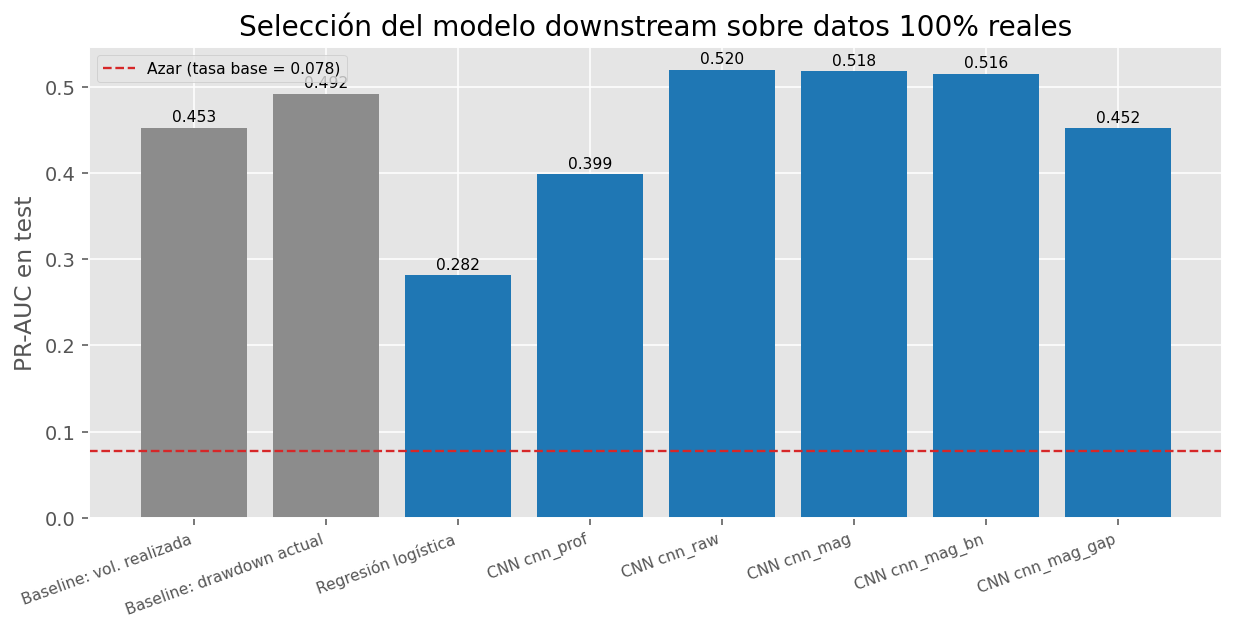

In [5]:
fig = plots.plot_model_comparison(tabla, metric="test_pr_auc", baseline_rate=float(split.y_test.mean()))
display(Image(str(fig)))

## Curvas de loss de la selección

El enunciado exige curvas de convergencia de **todos** los entrenamientos. Aquí están
las de las variantes de CNN; las de los generadores están en el notebook 03 y las de
las ~375 celdas del barrido se guardan una a una en `results/histories/`.

**Lo que hay que mirar en el gráfico.** En las primeras ~10 épocas, `loss` de train
cae casi a 0 y `pr_auc` de train llega a 1: la red memoriza. A partir de ahí,
`val_loss` (morada) sube y `val_pr_auc` (gris) hace un pico y baja: **sobreajuste
clásico**. Es el patrón esperado con solo ~14 episodios independientes de estrés y
una CNN de este tamaño.

Por eso hacemos dos cosas:

- **Early stopping en `val_pr_auc`**, no en la loss de train. La loss de train
  seguiría bajando aunque el modelo pierda capacidad de generalizar.
- **`restore_best_weights=True`**: al terminar, no nos quedamos con los pesos de la
  época 100, sino con los de la **mejor época de validación** (habitualmente entre
  la 2 y la 15). Ese modelo es el que se evalúa en test.

Entrenar hasta 100 épocas no es tirar tiempo: sirve para **ver el sobreajuste** de
forma explícita y justificar el criterio de parada. Las métricas finales en test
salen del pico temprano, no del final de la curva.

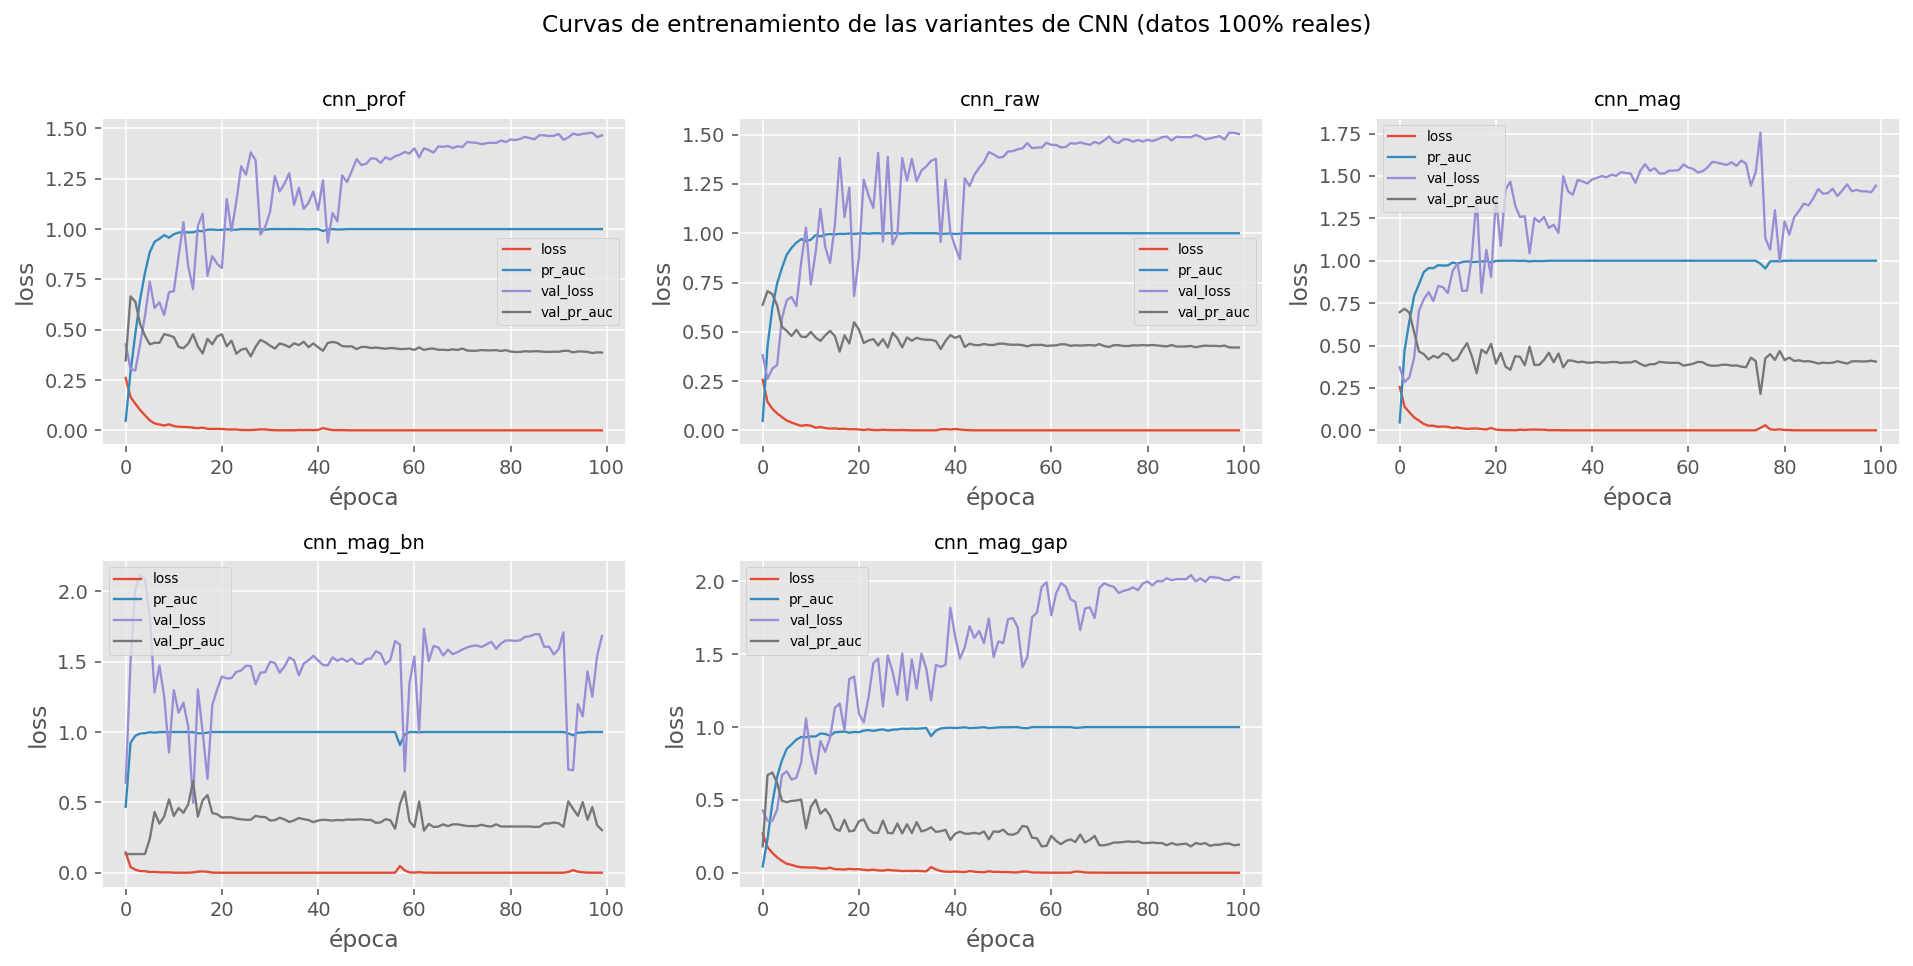

In [6]:
fig = plots.plot_loss_curves(
    historias, name="02_curvas_downstream",
    title="Curvas de entrenamiento de las variantes de CNN (datos 100% reales)",
)
display(Image(str(fig)))

## Arquitectura congelada

Elegimos **`cnn_mag`** y no se vuelve a tocar en todo el proyecto
(`config.DOWNSTREAM_VARIANT`).

**El criterio de selección es val_pr_auc**, no test: el test se reserva para el
reporte final. Con ese criterio `cnn_mag` tiene el mejor `val_pr_auc` (0,726),
seguida muy de cerca por `cnn_raw` (0,719): un empate técnico dentro del ruido
experimental.

El desempate lo decidimos **a priori**, no mirando la tabla:

- `cnn_mag` incorpora la capa `|r|`, que da acceso al **segundo momento** de la
  entrada. La etiqueta se calcula a partir de la volatilidad de la cartera, así
  que el modelo con acceso explícito a esa información es el que más sentido
  tiene desde el punto de vista del problema.

Esa justificación es independiente de cualquier número de test, y por eso nos
parece más defendible que un tie-breaker basado en métricas.

Como referencia adicional, y solo como reporte final (no como criterio), en test
`cnn_mag` mantiene la ventaja en ROC-AUC y recall respecto a `cnn_raw`, lo que
es coherente con su ventaja estructural.

Lo que sí es un resultado claro es el orden: **CNN > baselines financieros >
regresión logística**. La red aporta sobre el conocimiento experto, y el
problema no es linealmente separable.

In [7]:
modelo = downstream.build_classifier(split.input_shape, variant=config.DOWNSTREAM_VARIANT)
modelo.summary()
print(f"\nArquitectura congelada: {config.DOWNSTREAM_VARIANT}")
print(f"Épocas máximas: {config.DOWNSTREAM_EPOCHS} | batch: {config.DOWNSTREAM_BATCH} | paciencia: {config.DOWNSTREAM_PATIENCE}")

Model: "stress_cnn_mag"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 60, 23)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ magnitude_features_6            │ (None, 60, 46)         │             0 │
│ (MagnitudeFeatures)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 60, 64)         │         8,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 15, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        89,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,681 (674.54 KB)

 Trainable params: 172,681 (674.54 KB)

 Non-trainable params: 0 (0.00 B)


Arquitectura congelada: cnn_mag
Épocas máximas: 100 | batch: 128 | paciencia: 100


#### ***(Cabe notar, que como sabemos que te gustan mucho las curvas de aprendizaje, las primeras iteraciones eran muy feas. Si bien el train siempre disminuía, la validación era muy muy alta y subía a medida que aumentábamos las épocas, y nos invitaba a pensar en que había un sobreajuste. El modelo se sobreajusta, pero tengo entendido que esto es relativamente normal para este tipo de problemas. Por otro lado el accuracy si aumentaba, y el lift de aproximadamente 6,65, muy por encima del azar nos invita a pensar que aunque el modelo tienda a sobreajustarse, sí superan los baselines financieros)***